# 온라인 쇼핑 세션 군집화 (K-Means) - 행동 기반 방문자 세분화

지도학습 3종(Decision Tree / Random Forest / KNN)이 **"이 세션이 구매할까?"** 를 예측했다면,
이 노트북은 비지도 학습으로 **"방문자가 행동상 어떤 유형으로 나뉘는가, 유형별 구매율은 어떻게 다른가"** 를 분석한다.

핵심 원칙:
1. **`Revenue`(구매 여부)는 군집 학습에 사용하지 않는다.** 순수하게 행동 변수만으로 군집을 만든 뒤,
   사후에 군집별 실제 구매율을 붙여 해석/검증한다. (비지도의 정의를 지킴)
2. **KNN 전처리 입력을 그대로 재사용한다.** K-Means도 유클리드 거리 기반이라 KNN과 요구사항이 같다
   (ID 변수·Month 제외, 11개 수치 컬럼, `PageValues` 누수 변수 제외).
3. 군집은 기술적(descriptive) 분석이므로 train/test를 합친 전체 세션(중복 제거 후 12,205건)에 적용한다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (8, 4.5)

## 1. 데이터 로드

KNN 전처리 산출물(`models/knn/csv/`)을 재사용한다. 이 CSV는 `log1p`/스케일/SMOTE 적용 **전** 데이터라
군집용 전처리(log1p → 표준화)를 이 노트북에서 직접 수행한다. train/test를 모두 합쳐 전체 세션을 군집한다.


In [2]:
def find_knn_csv_dir():
    required = ['X_train_knn.csv', 'X_test_knn.csv', 'y_train_knn.csv', 'y_test_knn.csv']
    for base in [Path.cwd(), *Path.cwd().parents]:
        for cand in [base / 'models' / 'knn' / 'csv', base / 'knn' / 'csv', base / 'csv']:
            if all((cand / f).exists() for f in required):
                return cand
    raise FileNotFoundError('KNN 전처리 CSV를 찾지 못했습니다. preprocessing 노트북을 먼저 실행하세요.')

KNN_DIR = find_knn_csv_dir()

X_train = pd.read_csv(KNN_DIR / 'X_train_knn.csv')
X_test = pd.read_csv(KNN_DIR / 'X_test_knn.csv')
y_train = pd.read_csv(KNN_DIR / 'y_train_knn.csv')['Revenue']
y_test = pd.read_csv(KNN_DIR / 'y_test_knn.csv')['Revenue']

# 군집은 기술적 분석이므로 train/test 구분 없이 전체 세션을 사용한다.
X = pd.concat([X_train, X_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True)  # 사후 해석에만 사용, 학습에는 미사용

print(f'KNN CSV dir : {KNN_DIR}')
print(f'전체 세션   : {X.shape},  실제 구매율(참고용): {y.mean():.4f}')
print(f'사용 변수({X.shape[1]}개): {list(X.columns)}')
X.head()

KNN CSV dir : e:\shopper-prediction\models\knn\csv
전체 세션   : (12205, 11),  실제 구매율(참고용): 0.1563
사용 변수(11개): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'Weekend', 'is_new_visitor']


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,Weekend,is_new_visitor
0,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,0.0,0,0
1,0,0.0,0,0.0,30,901.288889,0.0,0.007333,0.0,0,1
2,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.8,0,0
3,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.0,1,1
4,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.0,0,0


## 2. 군집용 전처리 (log1p → 표준화)

K-Means는 거리 기반이라 스케일에 민감하다. 두 단계를 거친다.

1. **`log1p`** — 페이지 수/체류 시간/이탈률 등 강한 우편향 변수의 큰 값이 거리를 지배하지 않도록 압축.
2. **`StandardScaler`** — 모든 변수를 평균 0/표준편차 1로 맞춰 동등한 비중으로 거리 계산.

`Revenue`는 여기에 포함되지 않는다(비지도 유지). `Weekend`, `is_new_visitor`는 이미 0/1이라 log는 생략한다.


In [3]:
# KNN과 동일한 우편향 수치 컬럼에 log1p 적용
LOG_COLS = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'SpecialDay',
]

X_log = X.copy()
X_log[LOG_COLS] = np.log1p(X_log[LOG_COLS])

scaler = StandardScaler()
Z = scaler.fit_transform(X_log)

print(f'스케일링 완료: {Z.shape}')
print('변환 후 각 컬럼 평균(≈0)/표준편차(≈1) 확인:')
print(pd.DataFrame(Z, columns=X.columns).describe().loc[['mean', 'std']].round(3))

스케일링 완료: (12205, 11)
변환 후 각 컬럼 평균(≈0)/표준편차(≈1) 확인:
      Administrative  Administrative_Duration  Informational  Informational_Duration  ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  SpecialDay  Weekend  is_new_visitor
mean            -0.0                      0.0            0.0                     0.0            -0.0                     -0.0          0.0       -0.0        -0.0      0.0             0.0
std              1.0                      1.0            1.0                     1.0             1.0                      1.0          1.0        1.0         1.0      1.0             1.0


## 3. 군집 개수 K 선택 — 엘보우 + 실루엣

K는 "정답"이 없으므로 두 지표를 함께 본다.

- **엘보우(inertia)**: 군집 내 거리 제곱합. 꺾이는 지점(추가 군집의 이득이 줄어드는 곳)을 찾는다.
- **실루엣 계수**: 군집이 얼마나 뚜렷하게 분리됐는지(−1~1, 높을수록 좋음).

자동 argmax로 기계적으로 고르지 않고, 두 지표 + **해석 가능성**을 함께 근거로 K를 정한다.


 K     inertia  silhouette
 2 102581.6096      0.2328
 3  80645.5998      0.3225
 4  65272.1159      0.2753
 5  56185.6057      0.2993
 6  48222.5088      0.3218
 7  43893.8020      0.3274
 8  40877.3224      0.2944
 9  38527.4336      0.2914
10  36418.7173      0.3118


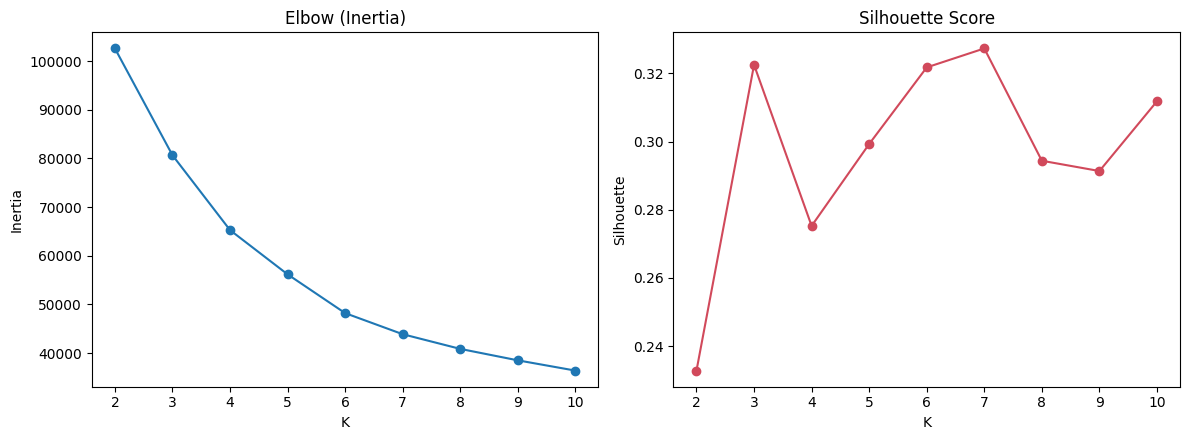

In [4]:
K_CANDIDATES = list(range(2, 11))
sweep = []
for k in K_CANDIDATES:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(Z)
    sil = silhouette_score(Z, labels, sample_size=4000, random_state=RANDOM_STATE)
    sweep.append({'K': k, 'inertia': km.inertia_, 'silhouette': sil})

sweep_df = pd.DataFrame(sweep)
print(sweep_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(sweep_df['K'], sweep_df['inertia'], marker='o')
axes[0].set_title('Elbow (Inertia)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(sweep_df['K'], sweep_df['silhouette'], marker='o', color='#d1495b')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

### K 선택 근거

- **엘보우**: inertia가 K=2→3에서 가장 크게 꺾인 뒤 완만해진다(굴절점 ≈ 3).
- **실루엣**: K=3에서 또렷한 국소 최댓값(≈0.32). 그 이상에서는 더 좋아지지 않거나 해석만 복잡해진다.
- **해석 가능성**: 아래에서 보듯 K=3은 *즉시 이탈 / 일반 탐색 / 고관여* 3단계로 깔끔하게 나뉘고
  구매율이 단조 증가해 보고서 서사로 가장 설득력 있다.

→ **K=3** 채택.


In [5]:
BEST_K = 3
kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(Z)

profile = X.copy()
profile['cluster'] = cluster_labels
profile['Revenue'] = y.values  # 사후 해석용으로만 결합

print(f'최종 군집 (K={BEST_K})')
print(profile['cluster'].value_counts().sort_index())

최종 군집 (K=3)
cluster
0    8988
1    2313
2     904
Name: count, dtype: int64


## 4. 군집 프로파일 — 각 유형은 어떤 방문자인가

원래 단위(역변환 불필요, 평균은 원본 스케일로 해석)로 군집별 평균을 본다.
어떤 행동 변수가 군집을 가르는지 확인한다.


In [6]:
profile_table = profile.groupby('cluster').agg(
    size=('Revenue', 'size'),
    purchase_rate=('Revenue', 'mean'),
    ProductRelated=('ProductRelated', 'mean'),
    ProductRelated_Duration=('ProductRelated_Duration', 'mean'),
    Administrative=('Administrative', 'mean'),
    BounceRates=('BounceRates', 'mean'),
    ExitRates=('ExitRates', 'mean'),
    is_new_visitor=('is_new_visitor', 'mean'),
    Weekend=('Weekend', 'mean'),
)
profile_table['size_pct'] = profile_table['size'] / profile_table['size'].sum()
print(profile_table.round(3).to_string())

         size  purchase_rate  ProductRelated  ProductRelated_Duration  Administrative  BounceRates  ExitRates  is_new_visitor  Weekend  size_pct
cluster                                                                                                                                         
0        8988          0.150          26.305                  964.478           1.856        0.009      0.033           0.159    0.229     0.736
1        2313          0.240          65.822                 2604.715           5.113        0.007      0.022           0.102    0.275     0.190
2         904          0.004           2.705                   41.798           0.043        0.163      0.179           0.033    0.183     0.074


### 군집 해석 (네이밍)

| cluster | 규모 | 구매율 | 행동 특징 | 라벨 |
|---|---:|---:|---|---|
| 즉시 이탈형 | ~7% | **~0.4%** | 상품 페이지 ~3개·체류 ~40초, BounceRate/ExitRate 매우 높음 | **Bouncers** |
| 일반 탐색형 | ~74% | ~15% | 평균적 탐색(상품 ~26페이지), 전체의 다수 | **Browsers** |
| 고관여형 | ~19% | **~24%** | 상품 ~66페이지·체류 ~2,600초, Administrative 페이지도 많음 | **Engaged buyers** |

핵심 인사이트: **세션 깊이(ProductRelated 페이지 수·체류 시간)가 깊어질수록 구매율이 단조 상승**한다
(0.4% → 15% → 24%). 이탈률(Bounce/Exit)이 높은 군집은 거의 구매하지 않는다.


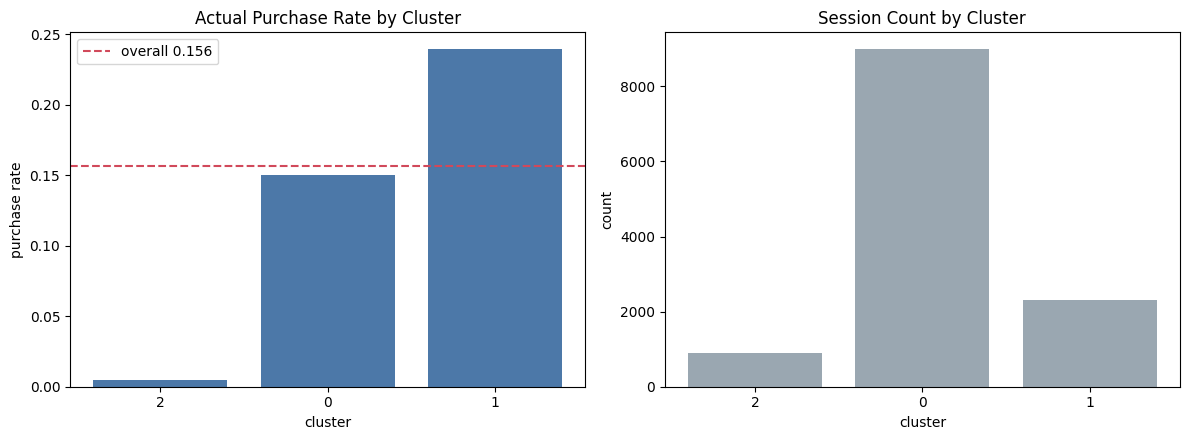

In [7]:
# 군집별 실제 구매율 (비지도 결과를 라벨로 검증)
order = profile_table.sort_values('purchase_rate').index
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(order.astype(str), profile_table.loc[order, 'purchase_rate'], color='#4c78a8')
axes[0].axhline(y.mean(), color='#d1495b', linestyle='--', label=f'overall {y.mean():.3f}')
axes[0].set_title('Actual Purchase Rate by Cluster')
axes[0].set_xlabel('cluster'); axes[0].set_ylabel('purchase rate'); axes[0].legend()

axes[1].bar(order.astype(str), profile_table.loc[order, 'size'], color='#9aa7b1')
axes[1].set_title('Session Count by Cluster')
axes[1].set_xlabel('cluster'); axes[1].set_ylabel('count')
plt.tight_layout()
plt.show()

## 5. 군집 × 범주형 교차 분석

행동 군집이 `is_new_visitor`, `Weekend` 같은 범주형 신호와 어떻게 겹치는지 본다.


In [8]:
cross_new = pd.crosstab(profile['cluster'], profile['is_new_visitor'], normalize='index').round(3)
cross_new.columns = ['returning(0)', 'new(1)']
print('군집별 신규/재방문 비율')
print(cross_new.to_string())

cross_wk = pd.crosstab(profile['cluster'], profile['Weekend'], normalize='index').round(3)
cross_wk.columns = ['weekday(0)', 'weekend(1)']
print('\n군집별 주중/주말 비율')
print(cross_wk.to_string())

군집별 신규/재방문 비율
         returning(0)  new(1)
cluster                      
0               0.841   0.159
1               0.898   0.102
2               0.967   0.033

군집별 주중/주말 비율
         weekday(0)  weekend(1)
cluster                        
0             0.771       0.229
1             0.725       0.275
2             0.817       0.183


## 6. PCA 2D 시각화

11차원 군집을 2개 주성분으로 투영해 분리 양상을 눈으로 확인한다.
(시각화 전용 — 군집 자체는 11차원 원공간에서 수행됨)


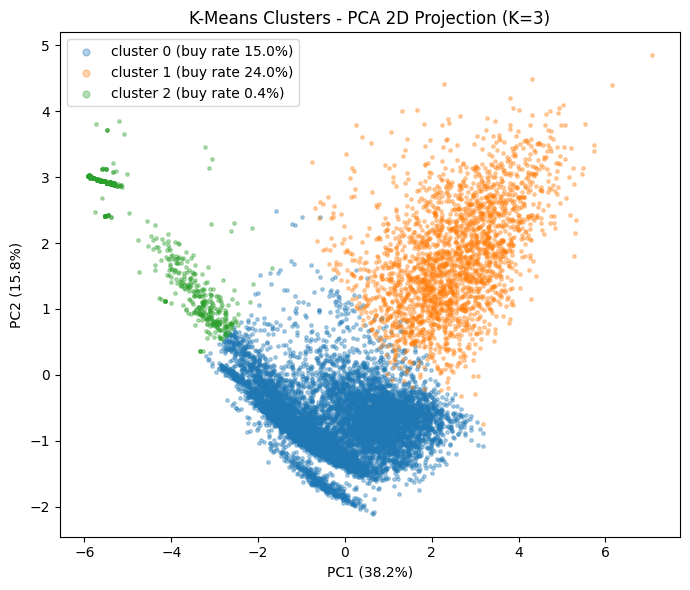

2개 주성분 누적 설명 분산: 54.0%


In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Z)

plt.figure(figsize=(7, 6))
for c in sorted(profile['cluster'].unique()):
    m = profile['cluster'] == c
    plt.scatter(coords[m, 0], coords[m, 1], s=6, alpha=0.35,
                label=f'cluster {c} (buy rate {profile_table.loc[c, "purchase_rate"]:.1%})')
plt.title(f'K-Means Clusters - PCA 2D Projection (K={BEST_K})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

print(f'2개 주성분 누적 설명 분산: {pca.explained_variance_ratio_.sum():.1%}')

## 7. 산출물 저장 + 결론

군집 라벨을 CSV로 저장해 다른 분석에서 재사용할 수 있게 한다.


In [10]:
out_dir = Path.cwd() / 'csv' if (Path.cwd().name == 'clustering') else Path.cwd() / 'models' / 'clustering' / 'csv'
out_dir.mkdir(parents=True, exist_ok=True)

cluster_assignment = profile[['cluster', 'Revenue']].copy()
cluster_assignment.to_csv(out_dir / 'cluster_assignment.csv', index=False)
profile_table.round(4).to_csv(out_dir / 'cluster_profile.csv')

print(f'저장: {out_dir / "cluster_assignment.csv"}')
print(f'저장: {out_dir / "cluster_profile.csv"}')

저장: e:\shopper-prediction\models\clustering\csv\cluster_assignment.csv
저장: e:\shopper-prediction\models\clustering\csv\cluster_profile.csv


### 결론 — 지도학습 3종과의 연결

- 군집화는 **행동 변수만으로** 방문자를 3개 유형(즉시이탈 / 일반탐색 / 고관여)으로 자동 분리했고,
  학습에 쓰지 않은 실제 구매율이 **0.4% → 15% → 24%** 로 단조 상승해 군집이 구매 성향과 잘 맞음을 검증했다.
- 이는 DT/RF/KNN 세 모델이 공통으로 `ProductRelated_Duration`·`ProductRelated`(세션 깊이) 변수에
  크게 의존한 결과와 **같은 신호를 가리킨다**: 예측 모델이 중요하게 본 축이 곧 군집을 가르는 축이다.
- 실무 함의: **고관여 군집**은 리타게팅·혜택 집중 대상, **일반 탐색 군집**은 구매 전환 유도(전환률 개선 여지가
  가장 큰 다수), **즉시 이탈 군집**은 랜딩/유입 품질 개선 대상으로 차등 전략을 세울 수 있다.
